# 1. Import Libraries, Configuration Setup, and Load the Dataset

## 1.1 Install \& Import Libraries

In [1]:
# !pip install peft==0.13.2, transformers==4.41.1

In [2]:
# !pip install wordcloud

In [3]:
# !pip install imblearn

In [4]:
# !pip install lightgbm

In [5]:
# ── Standard library ─────────────────────────────────────
import os
import re
import gc
import json
import time
import random
import warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Any, Dict, Tuple, Optional, List

# ── Core DS stack ────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── Scikit-learn ─────────────────────────────────────────
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    f1_score, roc_curve, auc, accuracy_score,
)
from sklearn.utils import resample, shuffle
from sklearn.utils.class_weight import compute_class_weight

# ── PyTorch ──────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ── Transformers ─────────────────────────────────────────
from transformers import (
    AutoTokenizer, AutoModel,
    AlbertModel, AlbertTokenizer,
    BertTokenizer,
)

# ── Notebook setup ───────────────────────────────────────
warnings.filterwarnings("ignore")


## 1.2 Seed \& Device

In [6]:
SEED = 2025

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 1.3 Configuration

In [7]:
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/NLP_Projects/03_DrugReview/07_AspectLabel_trained"
RAW_DATA_FILE = "data/drugscom_plus_ai_labels.csv"
OUTPUT_DIR = "outputs"

ALBERT_MODEL_NAME = "albert-base-v2"
BIOBERT_MODEL_NAME = "dmis-lab/biobert-base-cased-v1.2"

TEXT_COLUMN = "review"

# ── Aspect labels (3-class each) ─────────────────────────
ASPECT_NAMES = ["ai_efficacy", "ai_safety", "ai_burden", "ai_cost"]
ASPECT_CLASSES = ["NEGATIVE", "NEUTRAL", "POSITIVE"]
NUM_ASPECT_CLASSES = len(ASPECT_CLASSES)
ASPECT_LABEL_MAP = {v: i for i, v in enumerate(ASPECT_CLASSES)}

# ── LLM label source ────────────────────────────────────
EXPECTED_LABEL_SOURCE = "ai_4omini"

# ── Training config ──────────────────────────────────────
MAX_TOKEN_LENGTH = 200
BATCH_SIZE = 128                   # A100: large batches to saturate GPU
N_ITERATIONS = 10
RANDOM_STATE = 42
PATIENCE = 3
NUM_WORKERS = 4                    # A100 systems have more CPU cores

# ── A100 optimizations ──────────────────────────────────
USE_BF16 = torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8
USE_COMPILE = hasattr(torch, "compile")  # PyTorch 2.0+
print(f"BF16: {USE_BF16} | torch.compile: {USE_COMPILE}")

# ── Loss weights (λ) — clinically motivated 2211 ────────
# Efficacy & safety: primary clinical endpoints in drug evaluation
# Burden & cost: real-world adherence factors (post-marketing)
LOSS_WEIGHTS = {
    "ai_efficacy": 2.0,
    "ai_safety":   2.0,
    "ai_burden":   1.0,
    "ai_cost":     1.0,
}

# ── Retrain flag ─────────────────────────────────────────
RETRAIN = True

# ── Derived paths ────────────────────────────────────────
RAW_DATA_PATH = os.path.join(DRIVE_PROJECT_PATH, RAW_DATA_FILE)
OUTPUT_PATH = Path(DRIVE_PROJECT_PATH) / OUTPUT_DIR
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

MODEL_PATHS = {
    "albert": {
        "model":  OUTPUT_PATH / "best_albert_aspect.pth",
        "params": OUTPUT_PATH / "best_albert_aspect_params.json",
    },
    "biobert": {
        "model":  OUTPUT_PATH / "best_biobert_aspect.pth",
        "params": OUTPUT_PATH / "best_biobert_aspect_params.json",
    },
}

RAW_DATA_PATH = os.path.join(DRIVE_PROJECT_PATH, RAW_DATA_FILE)

print("--- Aspect-Only Multi-Task Configuration ---")
print(f"  Project    : {DRIVE_PROJECT_PATH}")
print(f"  Aspects    : {ASPECT_NAMES} × {NUM_ASPECT_CLASSES} classes")
print(f"  Loss wts   : {LOSS_WEIGHTS}")
print(f"  Batch size : {BATCH_SIZE}")


BF16: True | torch.compile: True
--- Aspect-Only Multi-Task Configuration ---
  Project    : /content/drive/MyDrive/NLP_Projects/03_DrugReview/01_R0/07_AspectLabel_trained
  Aspects    : ['ai_efficacy', 'ai_safety', 'ai_burden', 'ai_cost'] × 3 classes
  Loss wts   : {'ai_efficacy': 2.0, 'ai_safety': 2.0, 'ai_burden': 1.0, 'ai_cost': 1.0}
  Batch size : 128


## 1.4 Mount drive & Load the data

In [8]:
import os
if os.path.ismount("/content/drive"):
    # Already mounted, skip
    pass
else:
    !fusermount -u /content/drive 2>/dev/null
    !rm -rf /content/drive/*
    from google.colab import drive
    drive.mount("/content/drive/", force_remount=True)

df_raw = pd.read_csv(RAW_DATA_PATH, index_col=0).reset_index()
print(f"Loaded {df_raw.shape[0]} rows.")

Loaded 102061 rows.


In [9]:
df_raw = shuffle(df_raw, random_state=SEED).reset_index(drop=True)

# 2. Data Exploration \& Master Data Preparation

## 2.1 Master Data Preparation

### 2.1.1 Text cleaning

In [10]:
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", " urltoken ", text)
    text = re.sub(r"@\w+", " usertoken ", text)
    text = re.sub(r"#(\w+)", r" hashtag_\1 ", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


print("Cleaning text...")
df_clean = df_raw.copy()
df_clean[TEXT_COLUMN] = df_clean[TEXT_COLUMN].apply(clean_text)

Cleaning text...


### 2.1.2 Validate & encode aspect labels

In [11]:
print("\nAspect label distributions:")
for asp in ASPECT_NAMES:
    if asp not in df_clean.columns:
        raise ValueError(f"Missing column: {asp}")

    # Coerce any unexpected values (e.g., VERY_POSITIVE → POSITIVE)
    df_clean[asp] = df_clean[asp].str.upper().str.strip()
    df_clean[asp] = df_clean[asp].replace({
        "VERY_POSITIVE": "POSITIVE",
        "VERY_NEGATIVE": "NEGATIVE",
    })

    # Check validity
    valid_mask = df_clean[asp].isin(ASPECT_CLASSES)
    n_invalid = (~valid_mask).sum()
    if n_invalid > 0:
        print(f"  WARNING: {asp} has {n_invalid} invalid values — setting to NEUTRAL")
        df_clean.loc[~valid_mask, asp] = "NEUTRAL"

    # Encode to integer
    df_clean[f"{asp}_idx"] = df_clean[asp].map(ASPECT_LABEL_MAP).astype(int)
    print(f"  {asp}: {df_clean[asp].value_counts().to_dict()}")


Aspect label distributions:
  ai_efficacy: {'POSITIVE': 66326, 'NEGATIVE': 27971, 'NEUTRAL': 7764}
  ai_safety: {'NEGATIVE': 40703, 'NEUTRAL': 34519, 'POSITIVE': 26839}
  ai_burden: {'NEUTRAL': 54537, 'NEGATIVE': 34262, 'POSITIVE': 13262}
  ai_cost: {'NEUTRAL': 92376, 'NEGATIVE': 6474, 'POSITIVE': 3211}


## 2.3 Master Data Split

In [12]:
# Use first aspect as stratification proxy
y_for_split = df_clean["ai_efficacy_idx"]
groups = df_clean[TEXT_COLUMN]

# 80/20 → train+val / test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss_test.split(df_clean, y_for_split, groups=groups))

split = np.full(len(df_clean), "train", dtype=object)
split[test_idx] = "test"

# train → train + val (75/25 of 80% = 60/20)
df_trainval = df_clean.iloc[trainval_idx].copy().reset_index(drop=True)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx2, val_idx = next(
    gss_val.split(df_trainval, df_trainval["ai_efficacy_idx"],
                  groups=df_trainval[TEXT_COLUMN])
)
split[trainval_idx[val_idx]] = "val"
df_clean["split"] = split

print("\nSplit counts:")
print(df_clean["split"].value_counts())

# Leakage check
group_split_nunique = df_clean.groupby(TEXT_COLUMN)["split"].nunique()
n_leaky = (group_split_nunique > 1).sum()
assert n_leaky == 0, f"{n_leaky} text groups leak across splits!"
print("Leakage check passed.")

# Save
split_path = OUTPUT_PATH / "master_split_aspect.csv"
df_clean.to_csv(split_path, index=False)
print(f"Saved → {split_path}")


Split counts:
split
train    61309
test     20383
val      20369
Name: count, dtype: int64
Leakage check passed.
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/01_R0/07_AspectLabel_trained/outputs/master_split_aspect.csv


# 3. ALBERT \& BioBERT Models (Multi-aspect)

## 3.1 Shared helper functions

In [13]:
def bootstrap_f1_ci(y_true, y_pred, n_iterations=1000, average="weighted"):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(f1_score(y_true[idx], y_pred[idx], average=average))
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)


def bootstrap_auc_ci(y_true, y_scores, n_iterations=1000, average="macro"):
    y_true, y_scores = np.asarray(y_true), np.asarray(y_scores)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(
                roc_auc_score(y_true[idx], y_scores[idx],
                              average=average, multi_class="ovr")
            )
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)


def plot_confusion_matrix(y_true, y_pred, class_names, title="Model", save_dir=None):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {title}")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_confusion_matrix.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()


## 3.2 Data splits \& labels

In [14]:
df_train = df_clean[df_clean["split"] == "train"].copy()
df_val   = df_clean[df_clean["split"] == "val"].copy()
df_test  = df_clean[df_clean["split"] == "test"].copy()

train_texts = df_train[TEXT_COLUMN].astype(str).tolist()
val_texts   = df_val[TEXT_COLUMN].astype(str).tolist()
test_texts  = df_test[TEXT_COLUMN].astype(str).tolist()

# Aspect labels (hard, 3-class each)
y_train_aspects = {asp: df_train[f"{asp}_idx"].to_numpy(dtype=np.int64) for asp in ASPECT_NAMES}
y_val_aspects   = {asp: df_val[f"{asp}_idx"].to_numpy(dtype=np.int64) for asp in ASPECT_NAMES}
y_test_aspects  = {asp: df_test[f"{asp}_idx"].to_numpy(dtype=np.int64) for asp in ASPECT_NAMES}

print(f"Train: {len(train_texts)} | Val: {len(val_texts)} | Test: {len(test_texts)}")
for asp in ASPECT_NAMES:
    print(f"{asp}: {np.bincount(y_train_aspects[asp], minlength=NUM_ASPECT_CLASSES)}")

Train: 61309 | Val: 20369 | Test: 20383
ai_efficacy: [16958  4639 39712]
ai_safety: [24562 20703 16044]
ai_burden: [20686 32734  7889]
ai_cost: [ 3855 55504  1950]


## 3.3 Generic multi-task model componets

In [15]:
# ── Pre-tokenization ─────────────────────────────────────
def batch_tokenize(texts, tokenizer, max_len):
    enc = tokenizer(
        [str(t) for t in texts],
        truncation=True, padding="max_length",
        max_length=max_len, return_tensors="pt",
    )
    return enc["input_ids"], enc["attention_mask"]


# ── Aspect-Only Dataset ─────────────────────────────────
class AspectDataset(Dataset):
    """Pre-tokenized dataset with aspect labels only."""

    def __init__(self, input_ids, attention_masks, aspect_labels_dict):
        self.input_ids = input_ids
        self.attention_masks = attention_masks
        self.aspect_labels = {
            asp: np.asarray(labels, dtype=np.int64)
            for asp, labels in aspect_labels_dict.items()
        }

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        item = {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_masks[idx],
        }
        for asp in ASPECT_NAMES:
            item[f"{asp}_label"] = torch.tensor(
                self.aspect_labels[asp][idx], dtype=torch.long
            )
        return item


# ── Aspect-Only Classifier ──────────────────────────────
# ── Aspect Classifier with Learnable Task Weights ────────
class AspectTransformerLearned(nn.Module):
    """Shared backbone + 4 aspect heads + learnable uncertainty weights
    (Kendall et al., 2018)."""

    def __init__(self, base_model, hidden_size,
                 num_aspect_classes=NUM_ASPECT_CLASSES,
                 dropout=0.1):
        super().__init__()
        self.base = base_model
        self.dropout = nn.Dropout(dropout)
        self.aspect_heads = nn.ModuleDict({
            asp: nn.Linear(hidden_size, num_aspect_classes)
            for asp in ASPECT_NAMES
        })
        # Learnable log-variance per task (init=0 → equal weights)
        self.log_vars = nn.ParameterDict({
            asp: nn.Parameter(torch.zeros(1))
            for asp in ASPECT_NAMES
        })

    def forward(self, input_ids, attention_mask):
        out = self.base(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return {asp: head(cls) for asp, head in self.aspect_heads.items()}

    def compute_loss(self, task_losses):
        """L = Σ 0.5 * exp(-log_σ²) * L_t + 0.5 * log_σ²"""
        total = torch.tensor(0.0, device=next(self.parameters()).device)
        for asp, loss in task_losses.items():
            precision = torch.exp(-self.log_vars[asp])
            total = total + 0.5 * precision * loss + 0.5 * self.log_vars[asp]
        return total

    def get_learned_weights(self):
        """Precision = exp(-log_var). Higher = more weight."""
        return {asp.replace('ai_', ''): round(torch.exp(-self.log_vars[asp]).item(), 4)
                for asp in ASPECT_NAMES}

# ── Class weights for each task ──────────────────────────
def compute_task_weights(labels, num_classes, device=DEVICE):
    """Compute balanced class weights for a single task."""
    unique = np.unique(labels)
    cw = compute_class_weight("balanced", classes=unique, y=labels)
    full_cw = np.ones(num_classes, dtype=np.float32)
    for cls_id, w in zip(unique, cw):
        full_cw[cls_id] = w
    return torch.tensor(full_cw, dtype=torch.float32).to(device)

def train_aspect_model_learned(model, train_loader, val_loader,
                               aspect_weights_dict,
                               lr=2e-5, max_epochs=8, patience=PATIENCE):
    model.to(DEVICE)

    # Separate LR: backbone + heads at base lr, log_vars at 100x
    base_params = [p for n, p in model.named_parameters() if "log_vars" not in n]
    logvar_params = [p for n, p in model.named_parameters() if "log_vars" in n]

    optimizer = torch.optim.AdamW([
        {"params": base_params, "lr": lr},
        {"params": logvar_params, "lr": 0.01},  # much higher for scalars
    ])

    aspect_criteria = {
        asp: nn.CrossEntropyLoss(weight=aspect_weights_dict[asp])
        for asp in ASPECT_NAMES
    }

    best_f1, best_state, best_epoch = -1.0, None, -1
    no_improve = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        epoch_losses = []
        for batch in train_loader:
            ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad()

            with torch.autocast("cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                aspect_logits = model(ids, mask)

                task_losses = {}
                for asp in ASPECT_NAMES:
                    asp_y = batch[f"{asp}_label"].to(DEVICE, non_blocking=True)
                    task_losses[asp] = aspect_criteria[asp](aspect_logits[asp], asp_y)

                # Learned uncertainty weighting
                loss = model.compute_loss(task_losses)

            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        train_loss = float(np.mean(epoch_losses))

        # ── Validate ─────────────────────────────────────
        model.eval()
        val_asp_preds = {asp: [] for asp in ASPECT_NAMES}
        val_asp_true  = {asp: [] for asp in ASPECT_NAMES}

        with torch.no_grad():
            for batch in val_loader:
                ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
                mask = batch["attention_mask"].to(DEVICE, non_blocking=True)

                with torch.autocast("cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                    aspect_logits = model(ids, mask)

                for asp in ASPECT_NAMES:
                    val_asp_preds[asp].extend(
                        aspect_logits[asp].float().argmax(dim=1).cpu().numpy()
                    )
                    val_asp_true[asp].extend(batch[f"{asp}_label"].numpy())

        asp_f1s = {}
        for asp in ASPECT_NAMES:
            asp_f1s[asp] = f1_score(val_asp_true[asp], val_asp_preds[asp],
                                    average="weighted")
        mean_f1 = np.mean(list(asp_f1s.values()))

        # Log learned weights
        lw = model.get_learned_weights()
        asp_str = " | ".join(f"{a.replace('ai_','')}={v:.3f}" for a, v in asp_f1s.items())
        w_str = " | ".join(f"{k}={v:.2f}" for k, v in lw.items())
        print(f"  Epoch {epoch}/{max_epochs} | Loss={train_loss:.4f} | "
              f"MeanF1={mean_f1:.4f} | {asp_str}")
        print(f"    Learned wts: {w_str}")

        if mean_f1 > best_f1:
            best_f1 = mean_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    if best_state:
        model.load_state_dict(best_state)

    # Report final weights
    final_w = model.get_learned_weights()
    print(f"\n  Final learned weights: {final_w}")

    return best_f1, model, best_epoch


# =========================================================
# EVALUATION
# =========================================================
def evaluate_aspects(model, test_loader, model_name, save_dir=None):
    """Evaluate all aspect heads with bootstrap CIs."""
    model.eval()
    all_asp_logits = {asp: [] for asp in ASPECT_NAMES}
    all_asp_true   = {asp: [] for asp in ASPECT_NAMES}

    with torch.no_grad():
        for batch in test_loader:
            ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)

            with torch.autocast("cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                aspect_logits = model(ids, mask)

            for asp in ASPECT_NAMES:
                all_asp_logits[asp].append(aspect_logits[asp].float().cpu().numpy())
                all_asp_true[asp].extend(batch[f"{asp}_label"].numpy())

    results = {}
    for asp in ASPECT_NAMES:
        asp_logits_np = np.concatenate(all_asp_logits[asp])
        asp_probs = torch.softmax(torch.tensor(asp_logits_np), dim=1).numpy()
        asp_preds = asp_probs.argmax(axis=1)
        asp_true = np.asarray(all_asp_true[asp])

        asp_short = asp.replace("ai_", "")
        print(f"\n{'='*60}")
        print(f"{model_name} — {asp_short.upper()} (3-class)")
        print(f"{'='*60}")
        print(classification_report(
            asp_true, asp_preds,
            labels=list(range(NUM_ASPECT_CLASSES)),
            target_names=ASPECT_CLASSES, digits=4, zero_division=0,
        ))

        f1_m, f1_lo, f1_hi = bootstrap_f1_ci(asp_true, asp_preds)
        print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

        plot_confusion_matrix(asp_true, asp_preds, ASPECT_CLASSES,
                              title=f"{model_name}_Aspect_{asp_short}",
                              save_dir=save_dir)

        results[asp] = {
            "y_true": asp_true, "y_pred": asp_preds, "y_prob": asp_probs,
            "f1_weighted": f1_m, "f1_ci": (f1_lo, f1_hi),
        }

    return results


def build_loaders(tokenizer, model_label):
    """Tokenize and build train/val/test loaders."""
    print(f"\nTokenizing for {model_label}...")
    train_ids, train_masks = batch_tokenize(train_texts, tokenizer, MAX_TOKEN_LENGTH)
    val_ids, val_masks     = batch_tokenize(val_texts, tokenizer, MAX_TOKEN_LENGTH)
    test_ids, test_masks   = batch_tokenize(test_texts, tokenizer, MAX_TOKEN_LENGTH)

    loader_kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                     pin_memory=True, persistent_workers=True)

    train_loader = DataLoader(
        AspectDataset(train_ids, train_masks, y_train_aspects),
        shuffle=True, **loader_kw)
    val_loader = DataLoader(
        AspectDataset(val_ids, val_masks, y_val_aspects),
        shuffle=False, **loader_kw)
    test_loader = DataLoader(
        AspectDataset(test_ids, test_masks, y_test_aspects),
        shuffle=False, **loader_kw)

    return train_loader, val_loader, test_loader


# ── Compute class weights ────────────────────────────────
aspect_weights = {
    asp: compute_task_weights(y_train_aspects[asp], NUM_ASPECT_CLASSES)
    for asp in ASPECT_NAMES
}
for asp in ASPECT_NAMES:
    print(f"{asp} class weights: {aspect_weights[asp].cpu().numpy().round(3)}")


ai_efficacy class weights: [1.205 4.405 0.515]
ai_safety class weights: [0.832 0.987 1.274]
ai_burden class weights: [0.988 0.624 2.59 ]
ai_cost class weights: [ 5.301  0.368 10.48 ]


## 3.4 ALBERT: 4-Aspect model training

In [16]:
print("\n" + "=" * 60)
print("ALBERT — Multi-Task Training")
print("=" * 60)


ALBERT — Multi-Task Training


### 3.4.1 Pre-tokenize

In [17]:
albert_tokenizer = AlbertTokenizer.from_pretrained(ALBERT_MODEL_NAME)
train_loader_albert, val_loader_albert, test_loader_albert = \
    build_loaders(albert_tokenizer, "ALBERT")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Tokenizing for ALBERT...


### 3.4.2 Hyperparameter tuning

In [ ]:
RETRAIN = True

if RETRAIN:
    set_seed()
    start = time.time()

    param_space = {
        "lr":      (np.log10(1e-5), np.log10(3e-5)),
        "epochs":  (6, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_albert, best_params_albert, best_albert = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="ALBERT Aspect Search (Learned Wts)"):
        hp = {
            "lr":      float(10 ** np.random.uniform(*param_space["lr"])),
            "epochs":  int(np.random.randint(*param_space["epochs"])),
            "dropout": float(np.random.uniform(*param_space["dropout"])),
        }

        base = AlbertModel.from_pretrained(ALBERT_MODEL_NAME)
        model = AspectTransformerLearned(
            base, base.config.hidden_size, dropout=hp["dropout"],
        )

        f1_val, model, best_ep = train_aspect_model_learned(
            model, train_loader_albert, val_loader_albert,
            aspect_weights,
            lr=hp["lr"], max_epochs=hp["epochs"],
        )

        if f1_val > best_f1_albert:
            best_f1_albert = f1_val
            best_params_albert = hp
            best_albert = model
            torch.save(model.state_dict(), MODEL_PATHS["albert"]["model"])

        gc.collect()
        torch.cuda.empty_cache()

    print(f"ALBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_albert:.4f}")
    print(f"Best params: {best_params_albert}")
    print(f"Learned weights: {best_albert.get_learned_weights()}")

    with open(MODEL_PATHS["albert"]["params"], "w") as f:
        json.dump(best_params_albert, f, indent=2)

else:
    with open(MODEL_PATHS["albert"]["params"]) as f:
        best_params_albert = json.load(f)
    base = AlbertModel.from_pretrained(ALBERT_MODEL_NAME)
    best_albert = AspectTransformerLearned(
        base, base.config.hidden_size,
        dropout=best_params_albert.get("dropout", 0.1),
    )
    best_albert.load_state_dict(
        torch.load(MODEL_PATHS["albert"]["model"], map_location=DEVICE)
    )

best_albert.to(DEVICE)
best_albert.eval()
print(f"Final learned weights: {best_albert.get_learned_weights()}")

ALBERT Aspect Search (Learned Wts):   0%|          | 0/10 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.bias             | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/8 | Loss=1.5029 | MeanF1=0.7530 | efficacy=0.787 | safety=0.717 | burden=0.653 | cost=0.855
    Learned wts: efficacy=1.61 | safety=1.60 | burden=1.52 | cost=1.49
  Epoch 2/8 | Loss=0.9731 | MeanF1=0.7308 | efficacy=0.853 | safety=0.696 | burden=0.581 | cost=0.793
    Learned wts: efficacy=1.92 | safety=1.64 | burden=1.58 | cost=1.61
  Epoch 3/8 | Loss=0.7472 | MeanF1=0.7796 | efficacy=0.837 | safety=0.734 | burden=0.702 | cost=0.845
    Learned wts: efficacy=2.10 | safety=1.72 | burden=1.74 | cost=1.92
  Epoch 4/8 | Loss=0.5148 | MeanF1=0.7765 | efficacy=0.840 | safety=0.733 | burden=0.701 | cost=0.832
    Learned wts: efficacy=2.65 | safety=1.81 | burden=1.92 | cost=2.15
  Epoch 5/8 | Loss=0.2507 | MeanF1=0.7577 | efficacy=0.826 | safety=0.727 | burden=0.692 | cost=0.785
    Learned wts: efficacy=3.18 | safety=1.88 | burden=1.96 | cost=2.93
  Epoch 6/8 | Loss=-0.0600 | MeanF1=0.7831 | efficacy=0.830 | safety=0.733 | burden=0.691 | cost=0.878
    Learned wts: efficacy=3.72 |

ALBERT Aspect Search (Learned Wts):  10%|█         | 1/10 [16:21<2:27:16, 981.78s/it]

...

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.bias             | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/9 | Loss=1.6758 | MeanF1=0.7341 | efficacy=0.750 | safety=0.694 | burden=0.656 | cost=0.836
    Learned wts: efficacy=1.50 | safety=1.42 | burden=1.39 | cost=1.40
  Epoch 2/9 | Loss=1.1478 | MeanF1=0.7506 | efficacy=0.792 | safety=0.707 | burden=0.688 | cost=0.816
    Learned wts: efficacy=1.74 | safety=1.54 | burden=1.53 | cost=1.50
  Epoch 3/9 | Loss=1.0022 | MeanF1=0.7393 | efficacy=0.821 | safety=0.714 | burden=0.669 | cost=0.754
    Learned wts: efficacy=1.88 | safety=1.64 | burden=1.59 | cost=1.51
  Epoch 4/9 | Loss=0.8424 | MeanF1=0.7791 | efficacy=0.835 | safety=0.719 | burden=0.709 | cost=0.854
    Learned wts: efficacy=1.97 | safety=1.61 | burden=1.66 | cost=1.81
  Epoch 5/9 | Loss=0.6912 | MeanF1=0.7610 | efficacy=0.847 | safety=0.715 | burden=0.679 | cost=0.803
    Learned wts: efficacy=2.23 | safety=1.73 | burden=1.76 | cost=2.05
  Epoch 6/9 | Loss=0.5246 | MeanF1=0.7729 | efficacy=0.851 | safety=0.724 | burden=0.689 | cost=0.827
    Learned wts: efficacy=2.54 | 

ALBERT Aspect Search (Learned Wts): 100%|██████████| 10/10 [2:06:25<00:00, 758.55s/it]


ALBERT tuning: 7585.5s | Best F1=0.7892
Best params: {'lr': 1.3794487962110207e-05, 'epochs': 7, 'dropout': 0.1832961717863146}
Learned weights: {'efficacy': 4.2591, 'safety': 2.0126, 'burden': 2.0145, 'cost': 4.3221}
Final learned weights: {'efficacy': 4.2591, 'safety': 2.0126, 'burden': 2.0145, 'cost': 4.3221}


### 3.4.3 Model evaluation


ALBERT — EFFICACY (3-class)
              precision    recall  f1-score   support

    NEGATIVE     0.8216    0.8352    0.8284      5541
     NEUTRAL     0.3276    0.5573    0.4126      1572
    POSITIVE     0.9459    0.8608    0.9014     13270

    accuracy                         0.8304     20383
   macro avg     0.6984    0.7511    0.7141     20383
weighted avg     0.8644    0.8304    0.8438     20383

Weighted F1: 0.8437  95% CI [0.8388, 0.8484]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/01_R0/07_AspectLabel_trained/outputs/ALBERT_Aspect_efficacy_confusion_matrix.png


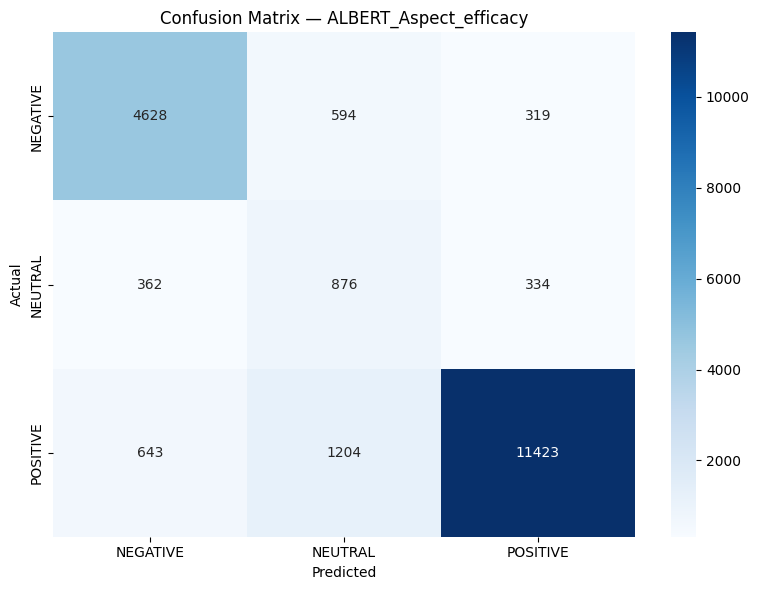


ALBERT — SAFETY (3-class)
              precision    recall  f1-score   support

    NEGATIVE     0.8420    0.7926    0.8166      8172
     NEUTRAL     0.6120    0.6228    0.6173      6858
    POSITIVE     0.7062    0.7536    0.7291      5353

    accuracy                         0.7252     20383
   macro avg     0.7201    0.7230    0.7210     20383
weighted avg     0.7290    0.7252    0.7266     20383

Weighted F1: 0.7266  95% CI [0.7206, 0.7322]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/01_R0/07_AspectLabel_trained/outputs/ALBERT_Aspect_safety_confusion_matrix.png


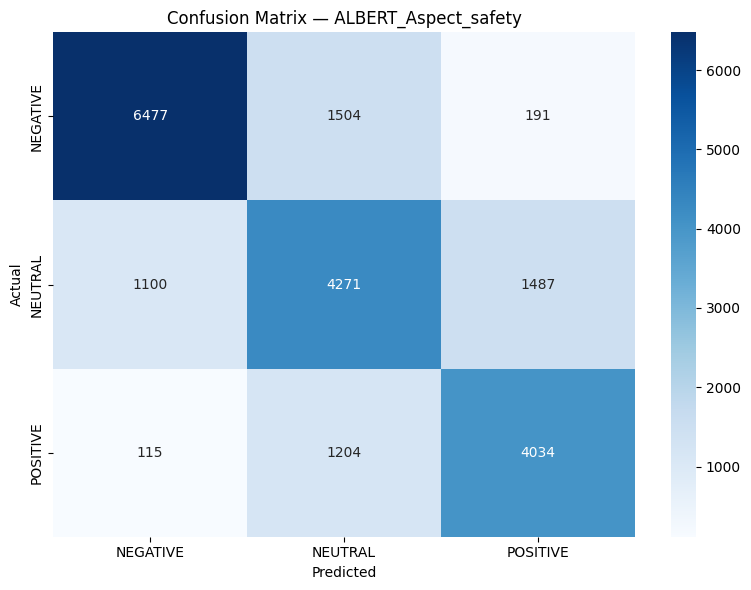


ALBERT — BURDEN (3-class)
              precision    recall  f1-score   support

    NEGATIVE     0.7366    0.8027    0.7682      6785
     NEUTRAL     0.7879    0.6101    0.6877     10950
    POSITIVE     0.4264    0.7262    0.5373      2648

    accuracy                         0.6893     20383
   macro avg     0.6503    0.7130    0.6644     20383
weighted avg     0.7238    0.6893    0.6950     20383

Weighted F1: 0.6949  95% CI [0.6886, 0.7008]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/01_R0/07_AspectLabel_trained/outputs/ALBERT_Aspect_burden_confusion_matrix.png


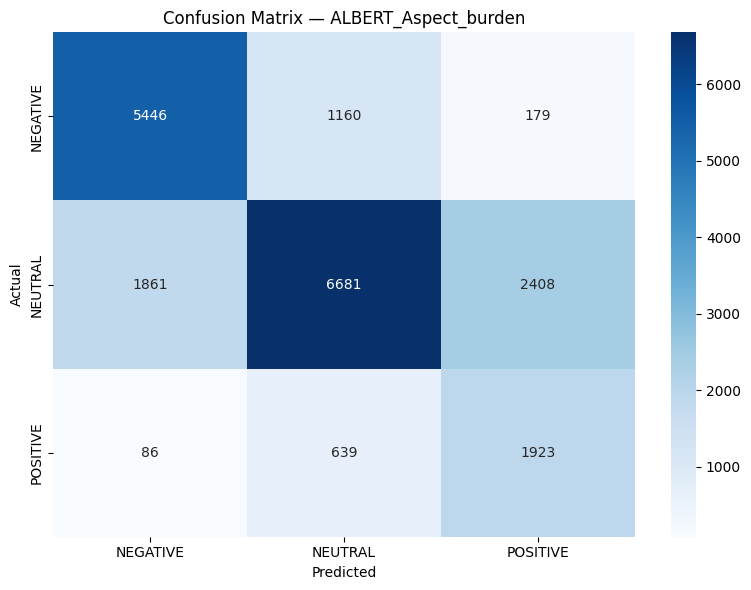


ALBERT — COST (3-class)
              precision    recall  f1-score   support

    NEGATIVE     0.3880    0.6141    0.4755      1306
     NEUTRAL     0.9635    0.8880    0.9242     18467
    POSITIVE     0.2755    0.5852    0.3746       610

    accuracy                         0.8614     20383
   macro avg     0.5423    0.6958    0.5915     20383
weighted avg     0.9060    0.8614    0.8790     20383

Weighted F1: 0.8791  95% CI [0.8749, 0.8831]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/01_R0/07_AspectLabel_trained/outputs/ALBERT_Aspect_cost_confusion_matrix.png


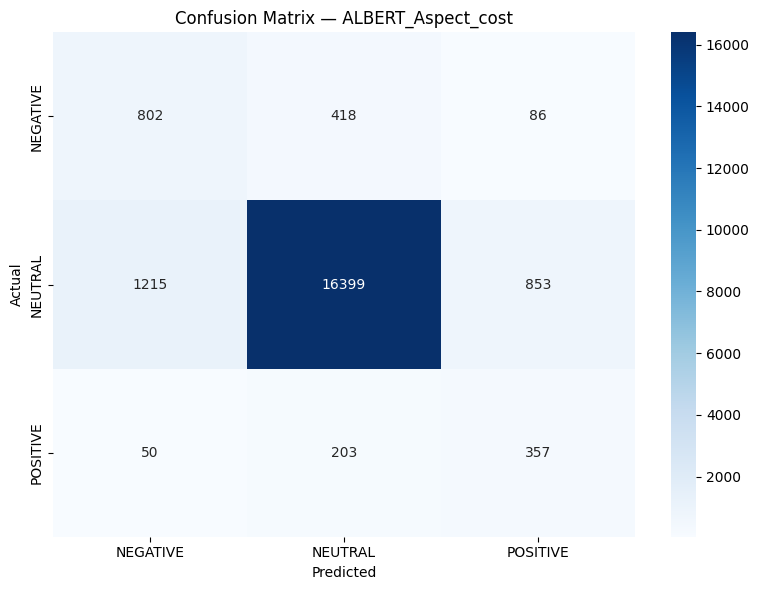

In [19]:
albert_results = evaluate_aspects(
    best_albert, test_loader_albert, "ALBERT", save_dir=str(OUTPUT_PATH)
)

In [20]:
# ── Print final learned weights ──────────────────────────
print("\n" + "=" * 60)
print("LEARNED TASK WEIGHTS")
print("=" * 60)

raw_w = best_albert.get_learned_weights()

# Normalize to sum=6 (comparable to 2+2+1+1 scale)
total = sum(raw_w.values())
norm_w = {k: round(v / total * 6, 2) for k, v in raw_w.items()}

print(f"\nALBERT:")
print(f"  Raw precision:  {raw_w}")
print(f"  Normalized (Σ=6): {norm_w}")
print(f"  Rank: {' > '.join(k for k, v in sorted(norm_w.items(), key=lambda x: -x[1]))}")


LEARNED TASK WEIGHTS

ALBERT:
  Raw precision:  {'efficacy': 4.2591, 'safety': 2.0126, 'burden': 2.0145, 'cost': 4.3221}
  Normalized (Σ=6): {'efficacy': 2.03, 'safety': 0.96, 'burden': 0.96, 'cost': 2.06}
  Rank: cost > efficacy > safety > burden


## 3.5 BioBERT: 4-Aspect model training

In [21]:
print("\n" + "=" * 60)
print("BioBERT — Multi-Task Training")
print("=" * 60)


BioBERT — Multi-Task Training


### 3.5.1 Pre-tokenize

In [22]:
biobert_tokenizer = BertTokenizer.from_pretrained(BIOBERT_MODEL_NAME)
train_loader_biobert, val_loader_biobert, test_loader_biobert = \
    build_loaders(biobert_tokenizer, "BioBERT")

vocab.txt: 0.00B [00:00, ?B/s]


Tokenizing for BioBERT...


### 3.5.2 Hyperparameter tuning

In [ ]:
RETRAIN = True

if RETRAIN:
    set_seed()
    start = time.time()

    param_space = {
        "lr":      (np.log10(1e-5), np.log10(3e-5)),
        "epochs":  (6, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_biobert, best_params_biobert, best_biobert = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="BioBERT Aspect Search (Learned Wts)"):
        hp = {
            "lr":      float(10 ** np.random.uniform(*param_space["lr"])),
            "epochs":  int(np.random.randint(*param_space["epochs"])),
            "dropout": float(np.random.uniform(*param_space["dropout"])),
        }

        base = AutoModel.from_pretrained(BIOBERT_MODEL_NAME)
        model = AspectTransformerLearned(
            base, base.config.hidden_size, dropout=hp["dropout"],
        )

        f1_val, model, best_ep = train_aspect_model_learned(
            model, train_loader_biobert, val_loader_biobert,
            aspect_weights,
            lr=hp["lr"], max_epochs=hp["epochs"],
        )

        if f1_val > best_f1_biobert:
            best_f1_biobert = f1_val
            best_params_biobert = hp
            best_biobert = model
            torch.save(model.state_dict(), MODEL_PATHS["biobert"]["model"])

        gc.collect()
        torch.cuda.empty_cache()

    print(f"BioBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_biobert:.4f}")
    print(f"Best params: {best_params_biobert}")
    print(f"Learned weights: {best_biobert.get_learned_weights()}")

    with open(MODEL_PATHS["biobert"]["params"], "w") as f:
        json.dump(best_params_biobert, f, indent=2)

else:
    with open(MODEL_PATHS["biobert"]["params"]) as f:
        best_params_biobert = json.load(f)
    base = AutoModel.from_pretrained(BIOBERT_MODEL_NAME)
    best_biobert = AspectTransformerLearned(
        base, base.config.hidden_size,
        dropout=best_params_biobert.get("dropout", 0.1),
    )
    best_biobert.load_state_dict(
        torch.load(MODEL_PATHS["biobert"]["model"], map_location=DEVICE)
    )

best_biobert.to(DEVICE)
best_biobert.eval()
print(f"Final learned weights: {best_biobert.get_learned_weights()}")

BioBERT Aspect Search (Learned Wts):   0%|          | 0/10 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/9 | Loss=1.4295 | MeanF1=0.7586 | efficacy=0.823 | safety=0.709 | burden=0.662 | cost=0.841
    Learned wts: efficacy=1.60 | safety=1.49 | burden=1.54 | cost=1.46
  Epoch 2/9 | Loss=0.9628 | MeanF1=0.7678 | efficacy=0.818 | safety=0.733 | burden=0.683 | cost=0.837
    Learned wts: efficacy=1.85 | safety=1.68 | burden=1.68 | cost=1.62
  Epoch 3/9 | Loss=0.6627 | MeanF1=0.7688 | efficacy=0.834 | safety=0.703 | burden=0.704 | cost=0.834
    Learned wts: efficacy=2.21 | safety=1.78 | burden=1.80 | cost=2.09
  Epoch 4/9 | Loss=0.3725 | MeanF1=0.7843 | efficacy=0.839 | safety=0.723 | burden=0.714 | cost=0.861
    Learned wts: efficacy=2.69 | safety=1.87 | burden=1.99 | cost=2.40
  Epoch 5/9 | Loss=0.1045 | MeanF1=0.7505 | efficacy=0.843 | safety=0.718 | burden=0.701 | cost=0.740
    Learned wts: efficacy=3.24 | safety=1.91 | burden=1.99 | cost=3.18
  Epoch 6/9 | Loss=-0.1702 | MeanF1=0.7605 | efficacy=0.831 | safety=0.720 | burden=0.674 | cost=0.817
    Learned wts: efficacy=3.82 |

BioBERT Aspect Search (Learned Wts): 100%|██████████| 10/10 [1:34:03<00:00, 564.37s/it]


BioBERT tuning: 5643.7s | Best F1=0.7949
Best params: {'lr': 2.9768448441450054e-05, 'epochs': 9, 'dropout': 0.22900784668310975}
Learned weights: {'efficacy': 5.5523, 'safety': 2.1433, 'burden': 2.2409, 'cost': 8.3706}
Final learned weights: {'efficacy': 5.5523, 'safety': 2.1433, 'burden': 2.2409, 'cost': 8.3706}


### 3.5.3 Model Evaluation


BioBERT — EFFICACY (3-class)
              precision    recall  f1-score   support

    NEGATIVE     0.8171    0.8078    0.8124      5541
     NEUTRAL     0.2914    0.5636    0.3842      1572
    POSITIVE     0.9391    0.8397    0.8867     13270

    accuracy                         0.8097     20383
   macro avg     0.6826    0.7370    0.6944     20383
weighted avg     0.8560    0.8097    0.8277     20383

Weighted F1: 0.8276  95% CI [0.8227, 0.8327]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/01_R0/07_AspectLabel_trained/outputs/BioBERT_Aspect_efficacy_confusion_matrix.png


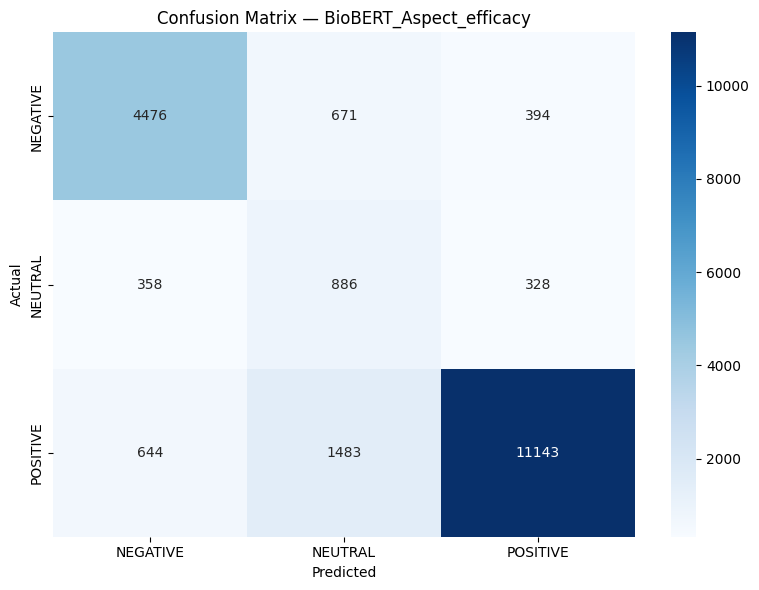


BioBERT — SAFETY (3-class)
              precision    recall  f1-score   support

    NEGATIVE     0.8273    0.8059    0.8165      8172
     NEUTRAL     0.6210    0.6328    0.6269      6858
    POSITIVE     0.7230    0.7338    0.7284      5353

    accuracy                         0.7287     20383
   macro avg     0.7237    0.7242    0.7239     20383
weighted avg     0.7305    0.7287    0.7295     20383

Weighted F1: 0.7296  95% CI [0.7235, 0.7356]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/01_R0/07_AspectLabel_trained/outputs/BioBERT_Aspect_safety_confusion_matrix.png


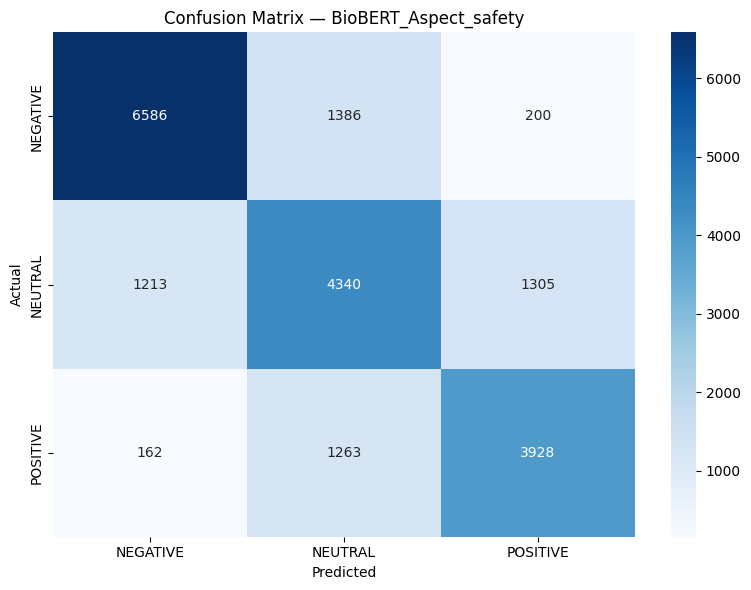


BioBERT — BURDEN (3-class)
              precision    recall  f1-score   support

    NEGATIVE     0.7334    0.7991    0.7648      6785
     NEUTRAL     0.7834    0.6412    0.7052     10950
    POSITIVE     0.4501    0.6847    0.5431      2648

    accuracy                         0.6994     20383
   macro avg     0.6556    0.7083    0.6711     20383
weighted avg     0.7235    0.6994    0.7040     20383

Weighted F1: 0.7040  95% CI [0.6981, 0.7101]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/01_R0/07_AspectLabel_trained/outputs/BioBERT_Aspect_burden_confusion_matrix.png


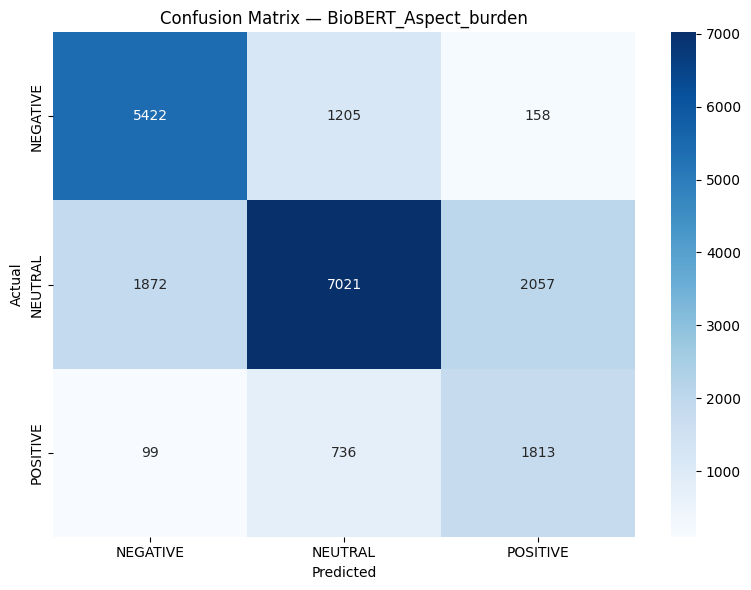


BioBERT — COST (3-class)
              precision    recall  f1-score   support

    NEGATIVE     0.5416    0.5835    0.5617      1306
     NEUTRAL     0.9586    0.9483    0.9534     18467
    POSITIVE     0.4051    0.4689    0.4347       610

    accuracy                         0.9106     20383
   macro avg     0.6351    0.6669    0.6499     20383
weighted avg     0.9153    0.9106    0.9128     20383

Weighted F1: 0.9128  95% CI [0.9089, 0.9168]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/01_R0/07_AspectLabel_trained/outputs/BioBERT_Aspect_cost_confusion_matrix.png


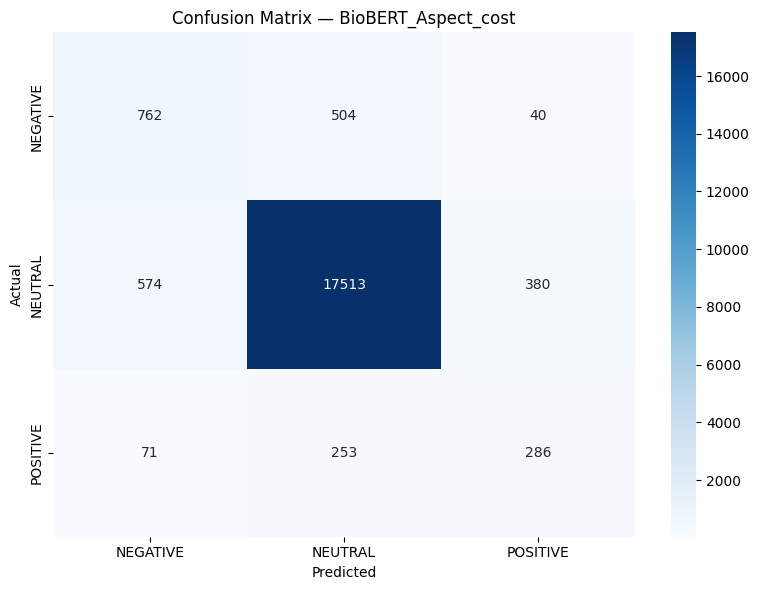

In [24]:
biobert_results = evaluate_aspects(
    best_biobert, test_loader_biobert, "BioBERT", save_dir=str(OUTPUT_PATH)
)

In [25]:
# ── Print final learned weights ──────────────────────────
print("\n" + "=" * 60)
print("LEARNED TASK WEIGHTS")
print("=" * 60)

raw_w = best_biobert.get_learned_weights()

# Normalize to sum=6 (comparable to 2+2+1+1 scale)
total = sum(raw_w.values())
norm_w = {k: round(v / total * 6, 2) for k, v in raw_w.items()}

print(f"\nBioBERT:")
print(f"  Raw precision:  {raw_w}")
print(f"  Normalized (Σ=6): {norm_w}")
print(f"  Rank: {' > '.join(k for k, v in sorted(norm_w.items(), key=lambda x: -x[1]))}")


LEARNED TASK WEIGHTS

BioBERT:
  Raw precision:  {'efficacy': 5.5523, 'safety': 2.1433, 'burden': 2.2409, 'cost': 8.3706}
  Normalized (Σ=6): {'efficacy': 1.82, 'safety': 0.7, 'burden': 0.73, 'cost': 2.74}
  Rank: cost > efficacy > burden > safety


## 3.6 Save Prediction

In [26]:
df_test_out = df_test[[TEXT_COLUMN]].copy()

# Aspect predictions
for asp in ASPECT_NAMES:
    asp_short = asp.replace("ai_", "")
    df_test_out[f"albert_{asp_short}_pred"] = albert_results[asp]["y_pred"]
    df_test_out[f"biobert_{asp_short}_pred"] = biobert_results[asp]["y_pred"]
    df_test_out[f"{asp_short}_true"] = albert_results[asp]["y_true"]

pred_path = OUTPUT_PATH / "test_predictions_aspect.csv"
df_test_out.to_csv(pred_path, index=False)
print(f"\nSaved predictions → {pred_path}")

# ── Summary ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("SUMMARY — Aspect-Only (2211 weights)")
print("=" * 60)
for model_name, results in [("ALBERT", albert_results), ("BioBERT", biobert_results)]:
    print(f"\n{model_name}:")
    f1s = []
    for asp in ASPECT_NAMES:
        r = results[asp]
        asp_short = asp.replace("ai_", "")
        print(f"  {asp_short:10s} F1: {r['f1_weighted']:.4f} "
              f"[{r['f1_ci'][0]:.4f}, {r['f1_ci'][1]:.4f}]")
        f1s.append(r['f1_weighted'])
    print(f"  {'MEAN':10s} F1: {np.mean(f1s):.4f}")


Saved predictions → /content/drive/MyDrive/NLP_Projects/03_DrugReview/01_R0/07_AspectLabel_trained/outputs/test_predictions_aspect.csv

SUMMARY — Aspect-Only (2211 weights)

ALBERT:
  efficacy   F1: 0.8437 [0.8388, 0.8484]
  safety     F1: 0.7266 [0.7206, 0.7322]
  burden     F1: 0.6949 [0.6886, 0.7008]
  cost       F1: 0.8791 [0.8749, 0.8831]
  MEAN       F1: 0.7861

BioBERT:
  efficacy   F1: 0.8276 [0.8227, 0.8327]
  safety     F1: 0.7296 [0.7235, 0.7356]
  burden     F1: 0.7040 [0.6981, 0.7101]
  cost       F1: 0.9128 [0.9089, 0.9168]
  MEAN       F1: 0.7935
